In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Better looking plots
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully!


In [2]:
nav = pd.read_csv("../Data/Processed/clean_nav.csv")

fund = pd.read_csv("../Data/Raw/01_fund_master.csv")

aum = pd.read_csv("../Data/Raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../Data/Raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../Data/Raw/05_category_inflows.csv")

folio = pd.read_csv("../Data/Raw/06_industry_folio_count.csv")

transactions = pd.read_csv("../Data/Processed/clean_transactions.csv")

performance = pd.read_csv("../Data/Processed/clean_performance.csv")

portfolio = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
datasets = {
    "NAV": nav,
    "Fund Master": fund,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folio": folio,
    "Transactions": transactions,
    "Performance": performance,
    "Portfolio": portfolio
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

NAV: (46000, 3)
Fund Master: (40, 15)
AUM: (90, 5)
SIP: (48, 6)
Category: (144, 3)
Folio: (21, 6)
Transactions: (32778, 13)
Performance: (40, 19)
Portfolio: (322, 8)


In [4]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Verify
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [5]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


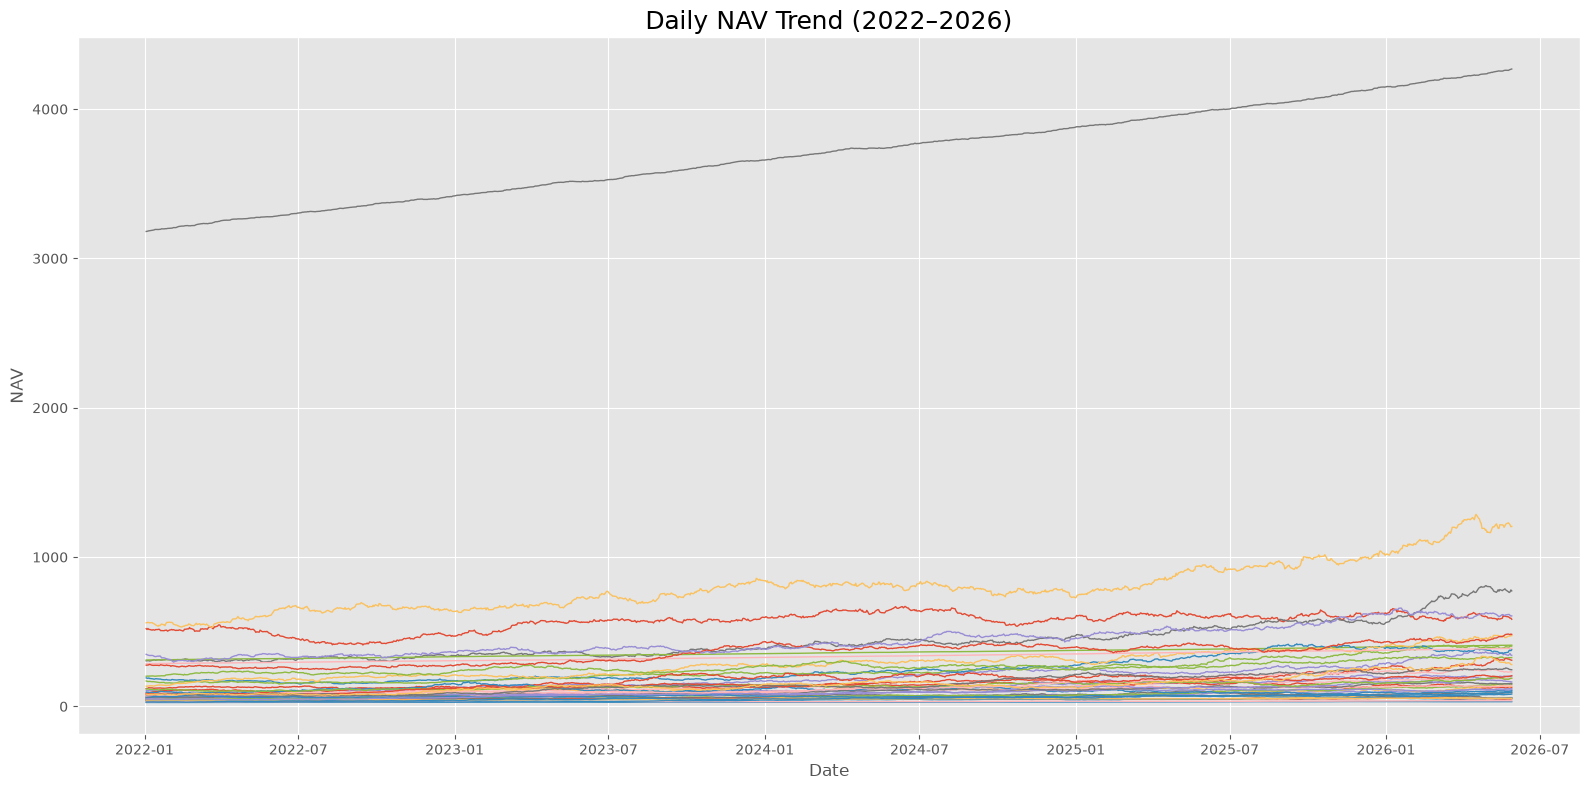

In [6]:
plt.figure(figsize=(16, 8))

for scheme in nav["scheme_name"].unique():
    data = nav[nav["scheme_name"] == scheme]
    plt.plot(
        data["date"],
        data["nav"],
        linewidth=1
    )

plt.title("Daily NAV Trend (2022–2026)", fontsize=18)
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.tight_layout()

plt.show()

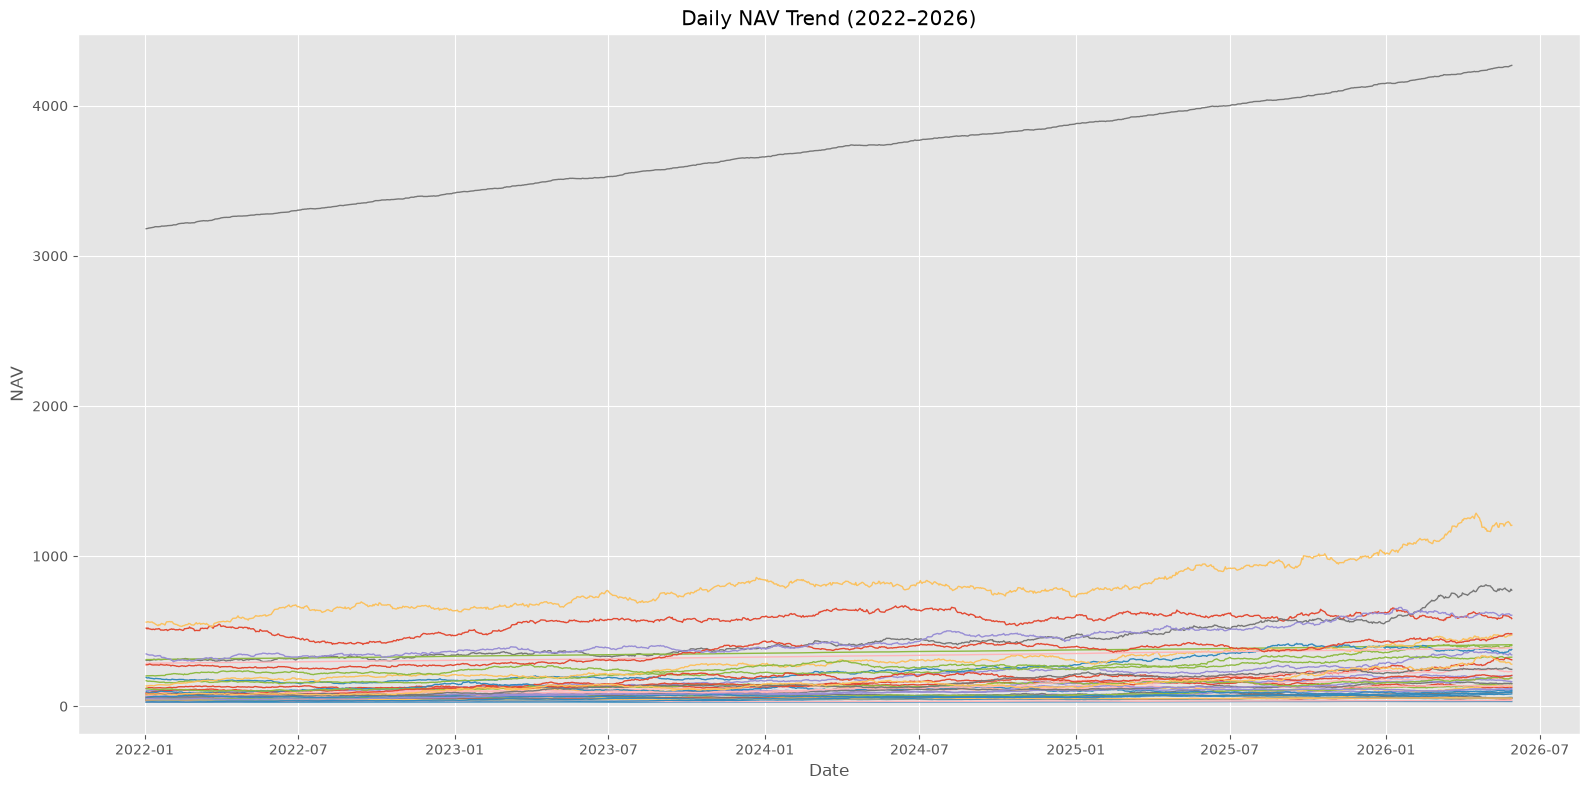

In [7]:
plt.figure(figsize=(16, 8))

for scheme in nav["scheme_name"].unique():
    data = nav[nav["scheme_name"] == scheme]
    plt.plot(data["date"], data["nav"], linewidth=1)

plt.title("Daily NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Charts/nav_trend_all_funds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- Daily NAV trends were plotted for all available mutual fund schemes.
- Most schemes show an overall upward trajectory during the observed period.
- Equity-oriented funds exhibit greater fluctuations than debt-oriented funds.
- Several funds display short-term corrections, followed by recoveries.
- Because 40 schemes are plotted together, the visualization is useful for identifying overall trends rather than comparing individual funds.

In [8]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [9]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [10]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [11]:
# Display first 10 rows
display(aum.head(10))

# Check unique fund houses
print("\nUnique Fund Houses:")
print(aum.iloc[:, 0].unique())

# Check available years
print("\nAvailable Years:")
print(aum.columns)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88



Unique Fund Houses:
<StringArray>
['2022-03-31', '2022-09-30', '2023-03-31', '2023-09-30', '2024-03-31',
 '2024-09-30', '2024-12-31', '2025-03-31', '2025-12-31']
Length: 9, dtype: str

Available Years:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


Why?

We're verifying:

Which column stores the AMC names.
Which columns store yearly AUM values.

In [12]:
print(aum.isnull().sum())

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64


In [13]:
display(aum.head(10))

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [14]:
# Find the largest AUM record
aum.sort_values(
    by="aum_lakh_crore",
    ascending=False
).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
71,2025-03-31,ICICI Prudential MF,8.80,880000,216
61,2024-12-31,ICICI Prudential MF,8.74,874000,216
30,2023-09-30,SBI Mutual Fund,8.45,845000,186


SBI Mutual Fund dominates the Indian Mutual Fund industry with an AUM of ₹12.5 lakh crore.

In [15]:
aum["date"] = pd.to_datetime(aum["date"])

aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[us]
 1   fund_house      90 non-null     str           
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 KB


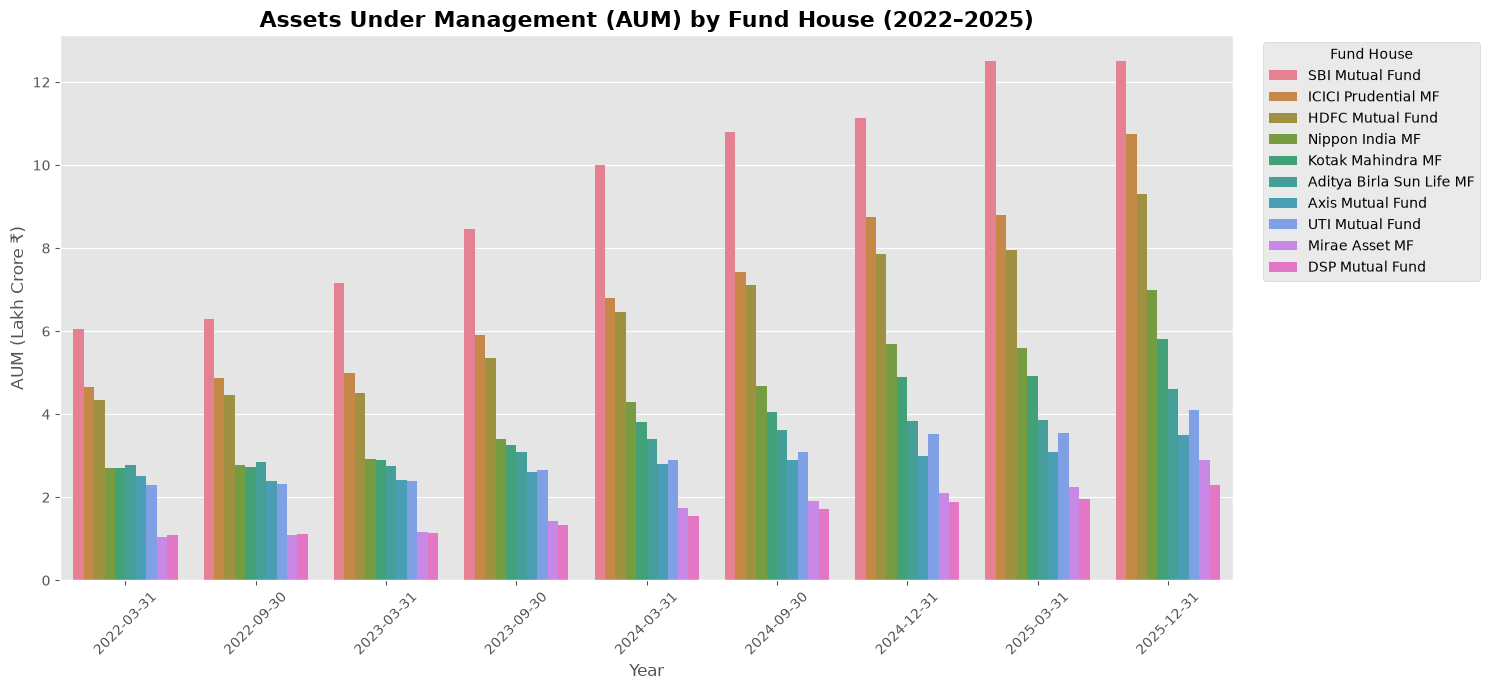

In [16]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Assets Under Management (AUM) by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=45)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

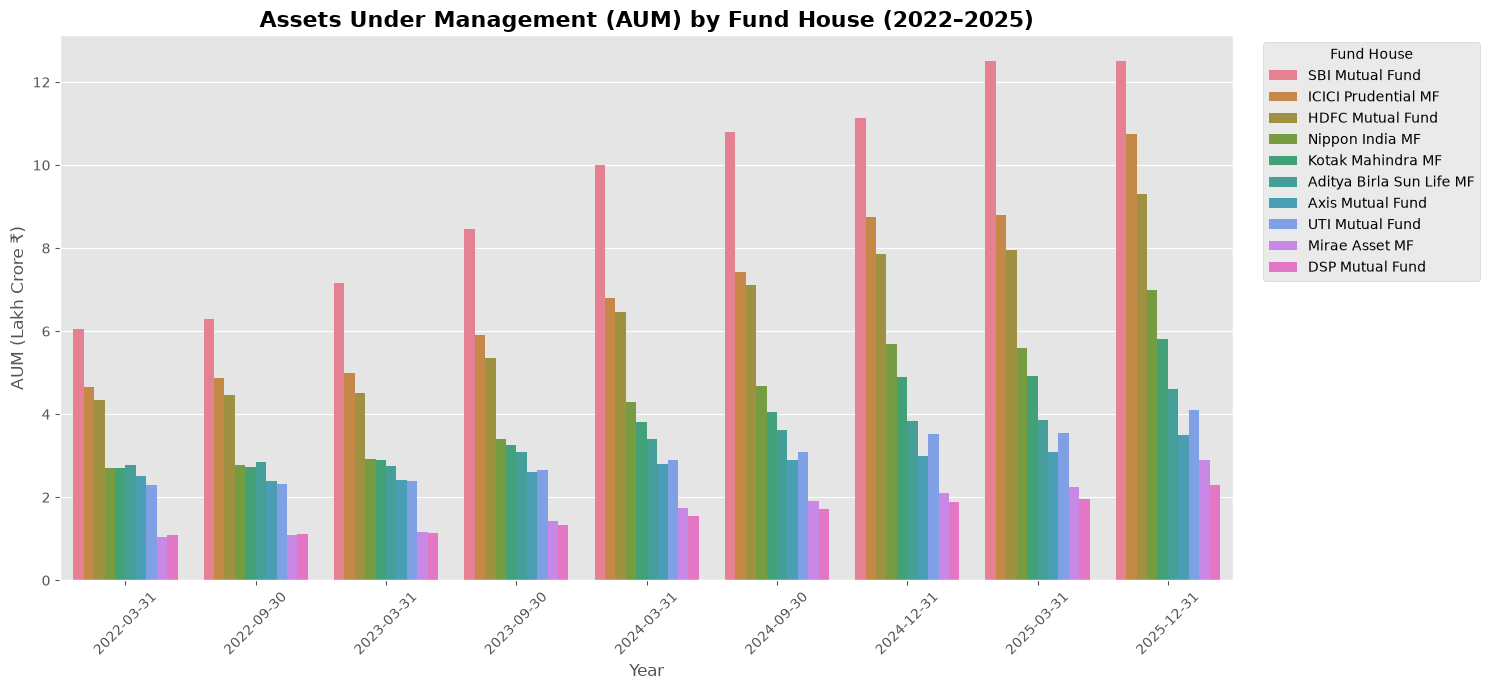

In [17]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Assets Under Management (AUM) by Fund House (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=45)

plt.legend(
    title="Fund House",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../Charts/aum_growth_by_amc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- SBI Mutual Fund consistently maintains one of the highest Assets Under Management (AUM) across the observed years.
- Most leading Asset Management Companies (AMCs) show steady AUM growth, indicating increasing investor participation.
- Mid-sized AMCs such as Mirae Asset and DSP Mutual Fund also demonstrate sustained growth, although at a lower scale.
- Overall industry AUM exhibits an upward trend, reflecting the expansion of India's mutual fund market.

In [18]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [19]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [20]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [22]:
sip["month"] = pd.to_datetime(sip["month"])

sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [23]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)

fig.show()

In [24]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

# Highlight maximum SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_scatter(
    x=[max_row["month"]],
    y=[max_row["sip_inflow_crore"]],
    mode="markers+text",
    text=[f'₹{max_row["sip_inflow_crore"]:,} Cr'],
    textposition="top center",
    marker=dict(size=12, color="red"),
    showlegend=False
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)

fig.show()

In [25]:
fig.write_html("../Charts/sip_inflow_trend.html")

In [30]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [32]:
import plotly

print("Plotly Version:", plotly.__version__)

Plotly Version: 6.8.0


In [33]:
import kaleido

print("Kaleido Imported Successfully!")

Kaleido Imported Successfully!


In [34]:
import plotly.io as pio

pio.write_image(
    fig,
    "../Charts/sip_inflow_trend.png",
    width=1400,
    height=700,
    scale=2
)

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


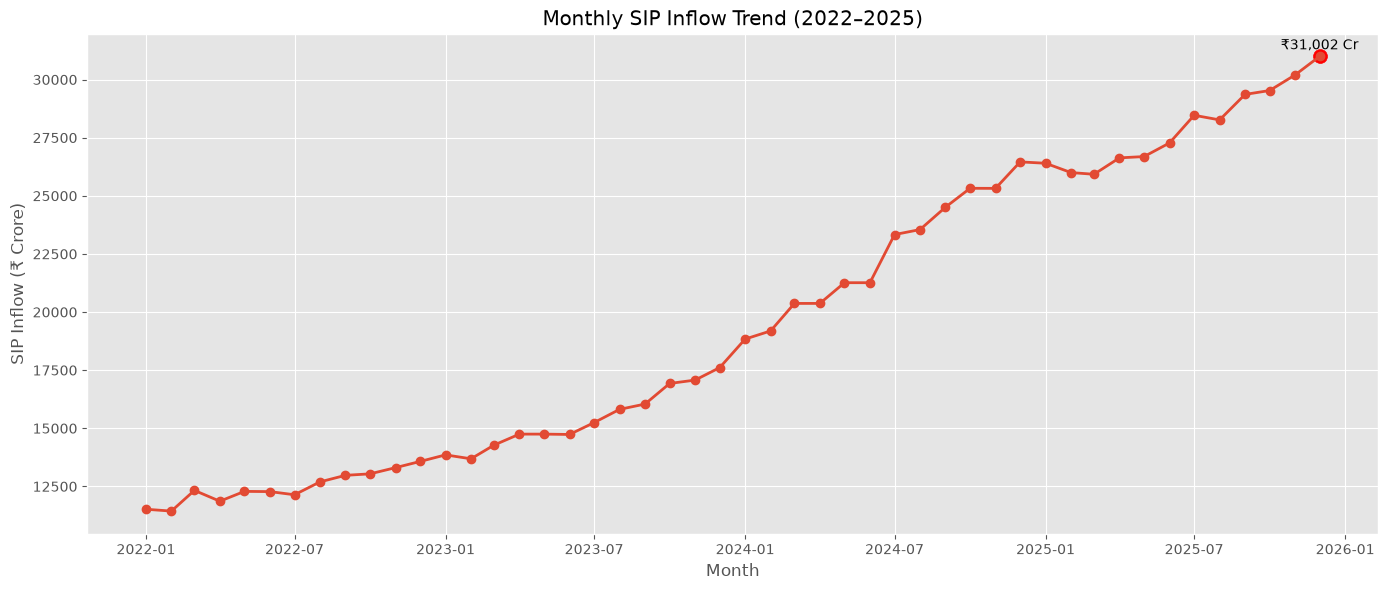

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

# Highlight maximum value
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.scatter(
    max_row["month"],
    max_row["sip_inflow_crore"],
    color="red",
    s=100
)

plt.text(
    max_row["month"],
    max_row["sip_inflow_crore"]+300,
    f'₹{max_row["sip_inflow_crore"]:,} Cr',
    ha="center",
    fontsize=10
)

plt.title("Monthly SIP Inflow Trend (2022–2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Charts/sip_inflow_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- Monthly SIP inflows show a consistent upward trend from 2022 to 2025.
- The highest SIP inflow is observed at approximately ₹31,002 crore, indicating strong retail investor participation.
- Increasing SIP inflows reflect growing confidence in mutual fund investments.
- The steady rise in active SIP accounts supports the long-term growth of the mutual fund industry.

In [36]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [37]:
category.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [38]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

In [39]:
category["month"] = pd.to_datetime(category["month"])

In [40]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


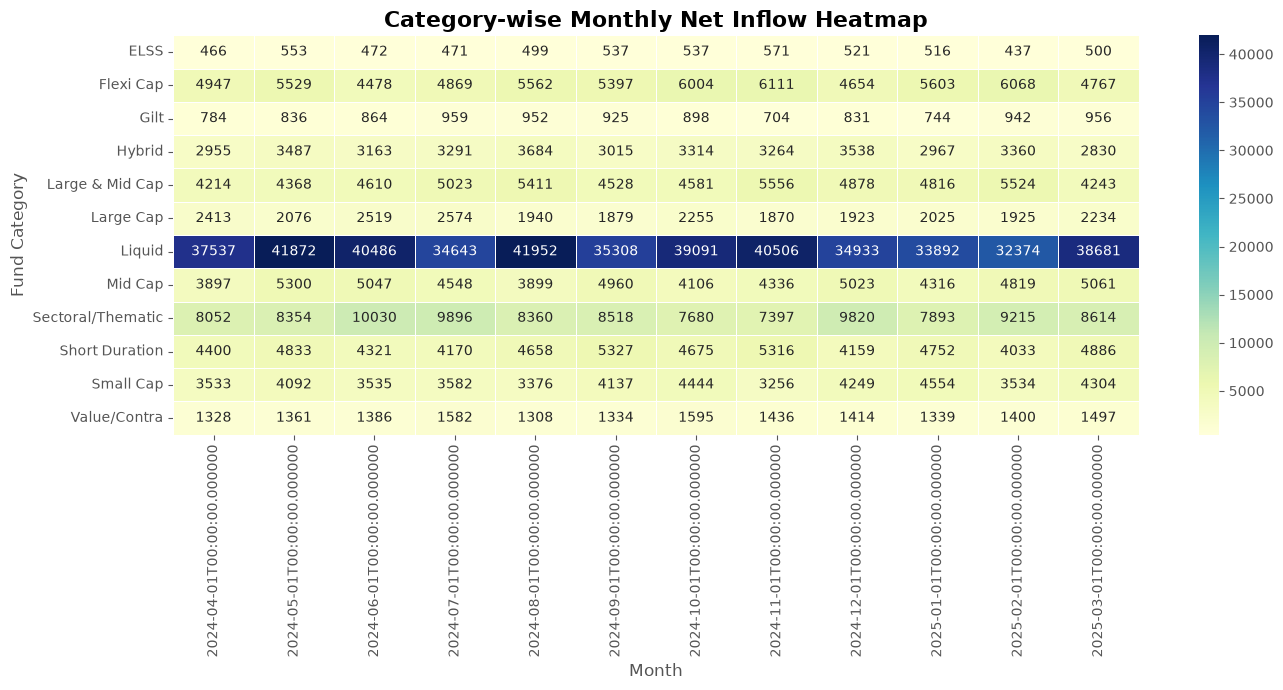

In [41]:
plt.figure(figsize=(14,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Category-wise Monthly Net Inflow Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../Charts/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- Flexi Cap, Mid Cap and Large & Mid Cap funds consistently attracted high investor inflows.
- Large Cap funds maintained stable inflows across the observed period.
- Small Cap funds experienced periods of strong inflows, reflecting increased investor risk appetite.
- The heatmap clearly highlights months with peak investments across different mutual fund categories.

In [42]:
transactions[["age_group", "amount_inr"]].head()

,age_group,amount_inr
0,56+,1834
1,18-25,392882
2,36-45,912
3,36-45,1102
4,26-35,8682


In [43]:
transactions["age_group"].value_counts()

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

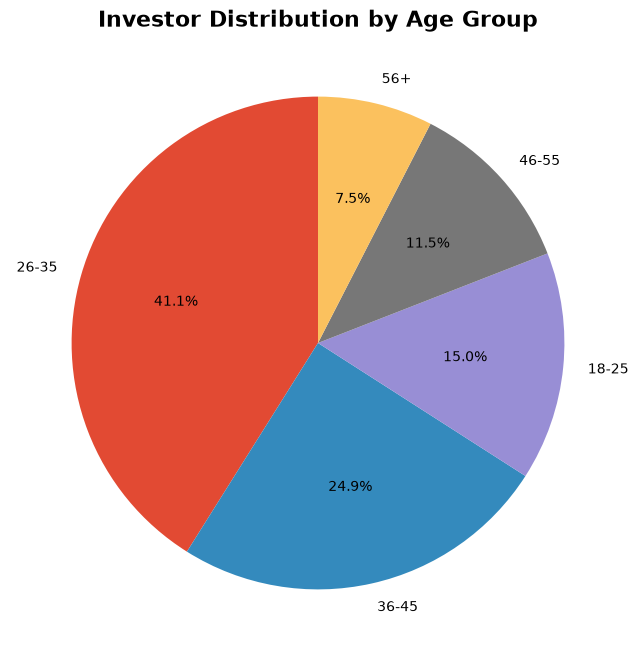

In [44]:
# Count investors in each age group
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "../Charts/age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

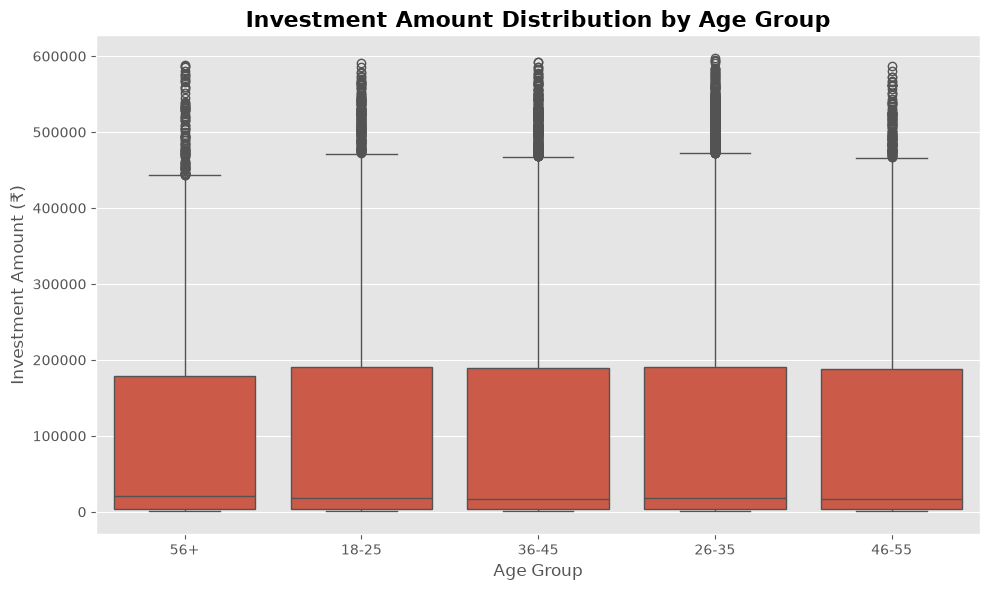

In [45]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "Investment Amount Distribution by Age Group",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../Charts/sip_amount_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- The investor base is distributed across all age groups.
- Younger investors (18–35 years) contribute significantly through SIP investments.
- Older investors generally exhibit a wider range of investment amounts, indicating higher investment capacity.
- The box plot highlights the spread, median and outliers in investment amounts across different age groups.

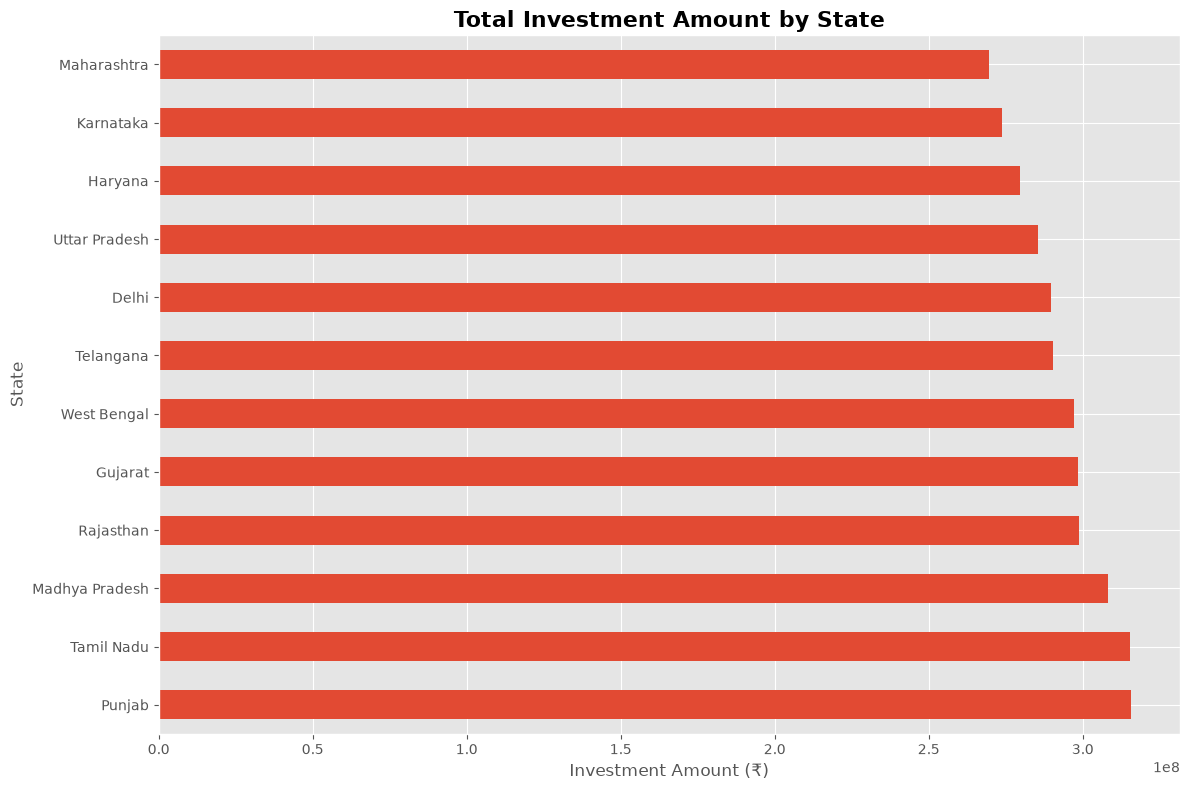

In [46]:
state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_sip.plot(kind="barh")

plt.title(
    "Total Investment Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../Charts/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

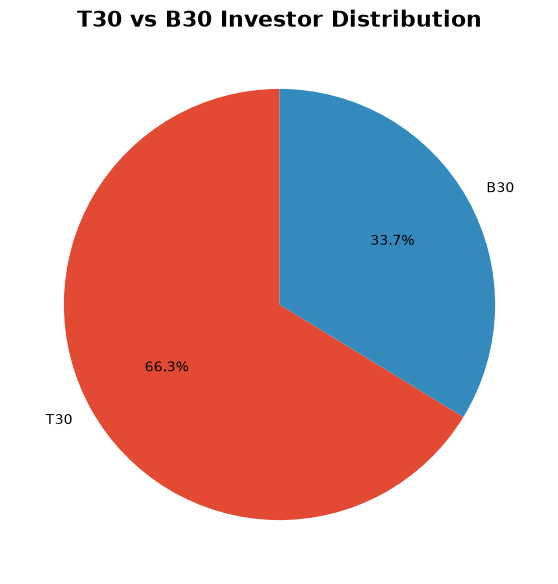

In [47]:
tier_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 Investor Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "../Charts/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- Major metropolitan states contribute the highest investment amounts.
- T30 cities account for a significant share of mutual fund investments.
- B30 cities continue to contribute meaningfully, reflecting increasing financial inclusion and mutual fund penetration beyond major urban centres.

In [48]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [49]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

In [50]:
folio["month"] = pd.to_datetime(folio["month"])

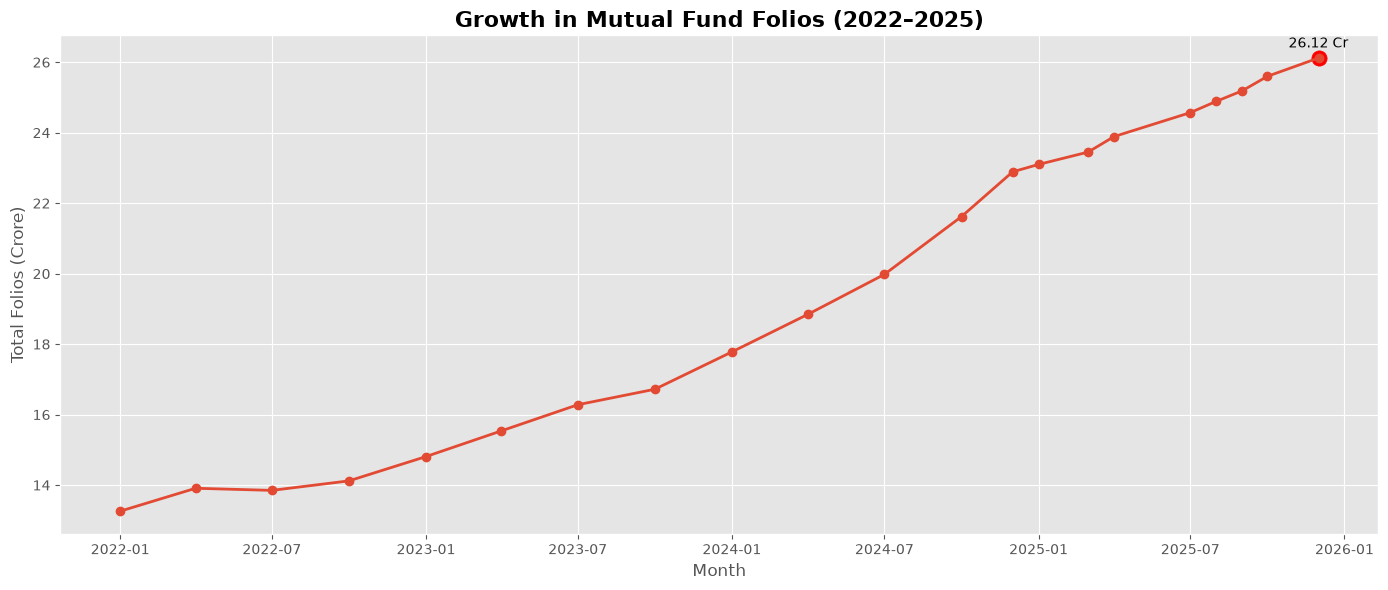

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2,
    label="Total Folios"
)

# Highlight maximum folio count
max_row = folio.loc[folio["total_folios_crore"].idxmax()]

plt.scatter(
    max_row["month"],
    max_row["total_folios_crore"],
    color="red",
    s=120
)

plt.text(
    max_row["month"],
    max_row["total_folios_crore"] + 0.3,
    f'{max_row["total_folios_crore"]:.2f} Cr',
    ha="center",
    fontsize=10
)

plt.title(
    "Growth in Mutual Fund Folios (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- Total mutual fund folios increased steadily from **13.26 crore** to over **26 crore**.
- The continuous rise in folio count reflects growing retail investor participation.
- Equity funds account for the largest share of folios throughout the observed period.

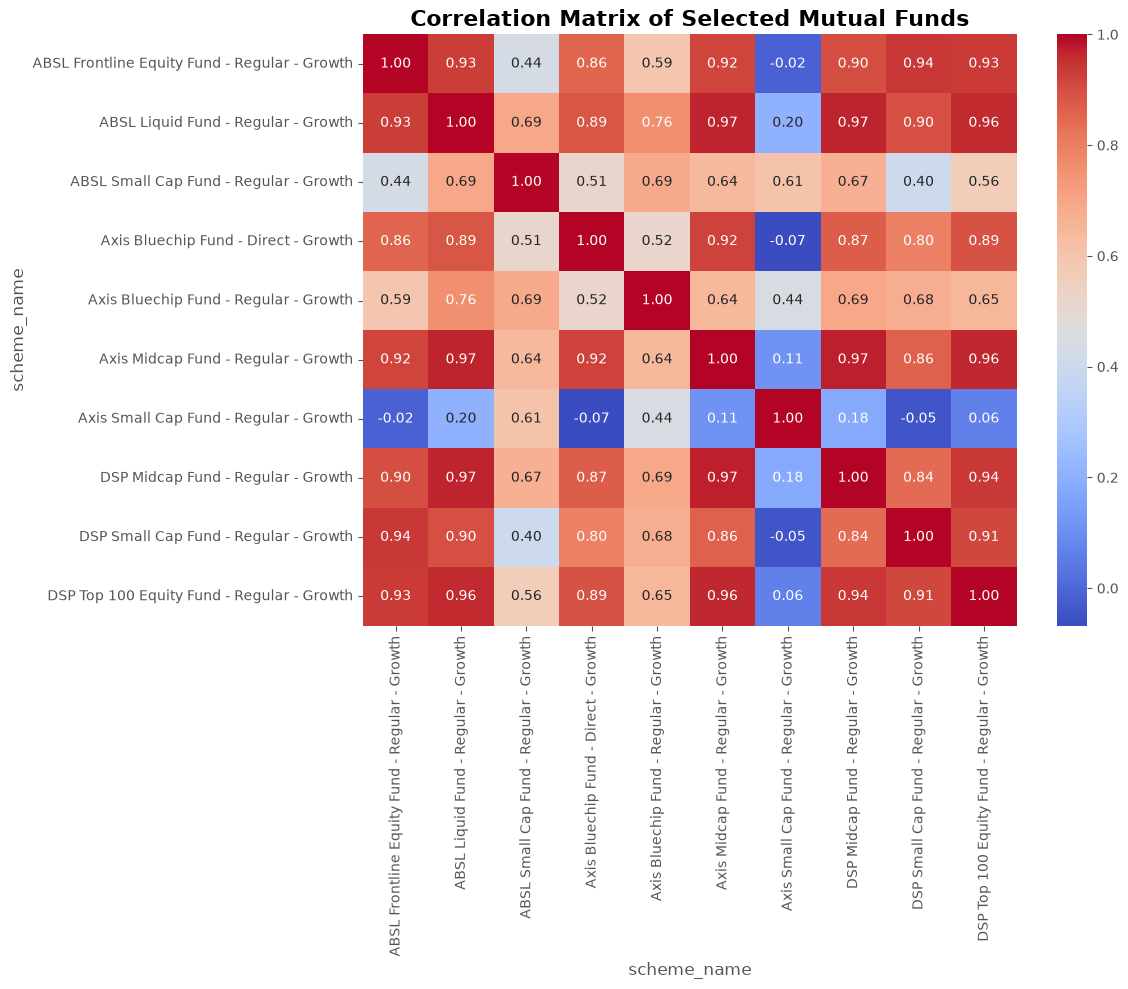

In [52]:
# Create pivot table
nav_pivot = nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

# Correlation for first 10 funds
corr_matrix = nav_pivot.iloc[:, :10].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Selected Mutual Funds",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Charts/nav_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [54]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [55]:
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

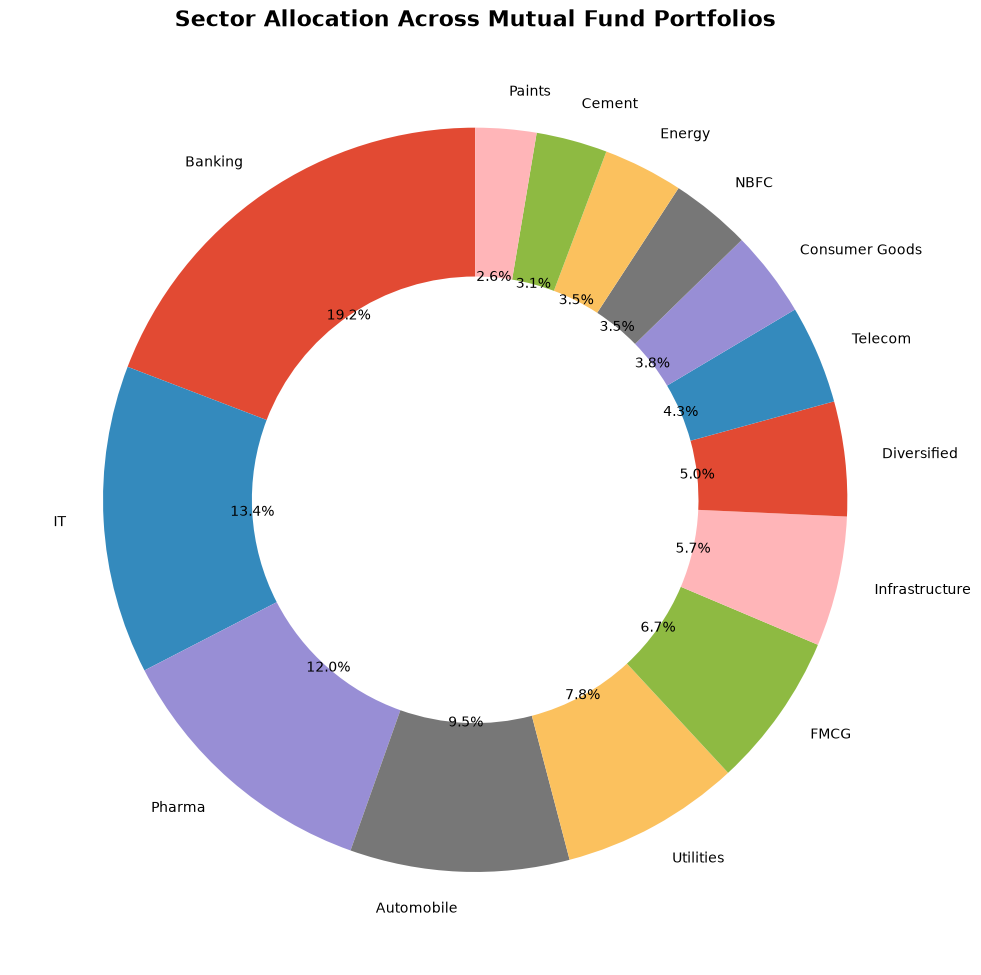

In [56]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title(
    "Sector Allocation Across Mutual Fund Portfolios",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../Charts/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insights

- Banking constitutes the largest allocation across mutual fund portfolios.
- Utilities, Diversified and Pharma sectors also hold significant portfolio weights.
- Sector diversification helps reduce concentration risk while maintaining long-term growth potential.

# Key EDA Findings

1. Mutual fund NAVs generally exhibited an upward trend from 2022 to 2025, with periodic market corrections.

2. SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM), reaching approximately ₹12.5 lakh crore.

3. ICICI Prudential MF and HDFC Mutual Fund remained among the top-performing AMCs in terms of AUM.

4. Monthly SIP inflows increased steadily and crossed ₹31,000 crore, indicating growing retail investor participation.

5. Flexi Cap, Mid Cap and Large & Mid Cap categories attracted strong investor inflows across multiple months.

6. Investors from all age groups participated actively, with younger investors contributing significantly through SIPs.

7. Major metropolitan states accounted for a large share of investment amounts, while B30 cities also showed increasing participation.

8. Total mutual fund folios increased from approximately 13.26 crore to over 26 crore, reflecting rapid industry expansion.

9. Correlation analysis showed that many equity funds move together, while diversification across categories can reduce portfolio risk.

10. Banking, Utilities, Pharma and Diversified sectors represented major allocations within mutual fund portfolios, demonstrating diversified investment strategies.